In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
from torch_geometric.data import Data

In [5]:
g1 = torch.load('data/credit_graph1.pt', weights_only=False)
g2 = torch.load('data/credit_graph2.pt', weights_only=False)
g3 = torch.load('data/credit_graph3.pt', weights_only=False)

In [8]:
print(g1)
print(g2)
print(g3)

Data(x=[408239, 17], edge_index=[287195, 2], y=[408239], edge_type=[287195])
Data(x=[568694, 17], edge_index=[410233, 2], y=[568694], edge_type=[410233])
Data(x=[85590, 17], edge_index=[48843, 2], y=[85590], edge_type=[48843])


In [10]:
print(pd.Series(g1['y']).value_counts())
print(pd.Series(g2['y']).value_counts())
print(pd.Series(g3['y']).value_counts())

0    405543
1      2696
Name: count, dtype: int64
0    564129
1      4565
Name: count, dtype: int64
0    84136
1     1454
Name: count, dtype: int64


In [11]:
from torch_geometric.utils import degree
import matplotlib.pyplot as plt
from collections import Counter

def plot_deg_dist(data, gid):
    out_deg = degree(data.edge_index[:,0], num_nodes=data.num_nodes, dtype=torch.long)
    in_deg = degree(data.edge_index[:,1], num_nodes=data.num_nodes, dtype=torch.long)
    total_deg = out_deg + in_deg
    
    # 将张量转换为numpy数组，并用Counter进行统计
    deg_count = Counter(total_deg.numpy())
    
    # 3. 绘制节点度分布图
    plt.figure(figsize=(8, 5))
    plt.bar(deg_count.keys(), deg_count.values(), color='skyblue', edgecolor='black')
    plt.xlabel('Node Degree', fontsize=12)
    plt.ylabel('Number of Nodes', fontsize=12)
    plt.title('Degree Distribution of Graph: '+str(gid), fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7) # 可选：添加网格辅助线
    plt.tight_layout()
    plt.show()

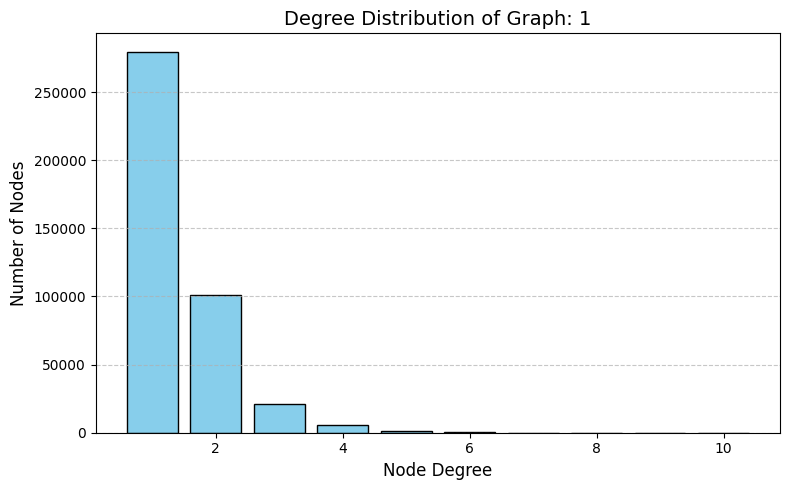

In [12]:
plot_deg_dist(g1, gid=1)

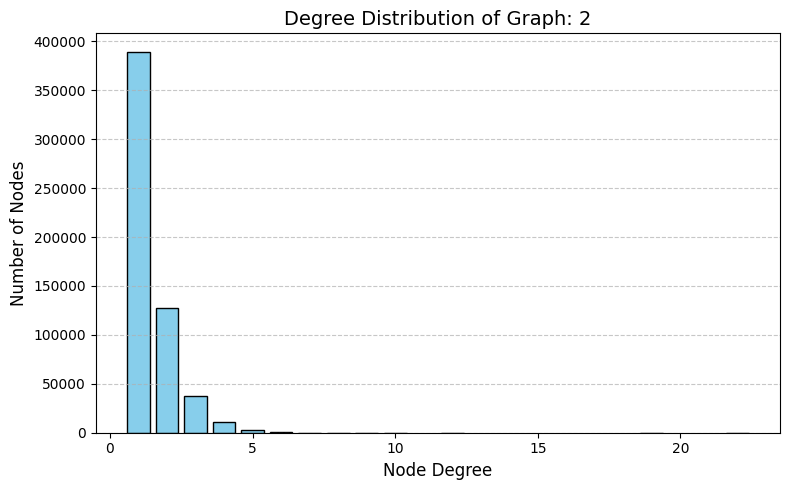

In [13]:
plot_deg_dist(g2, gid=2)

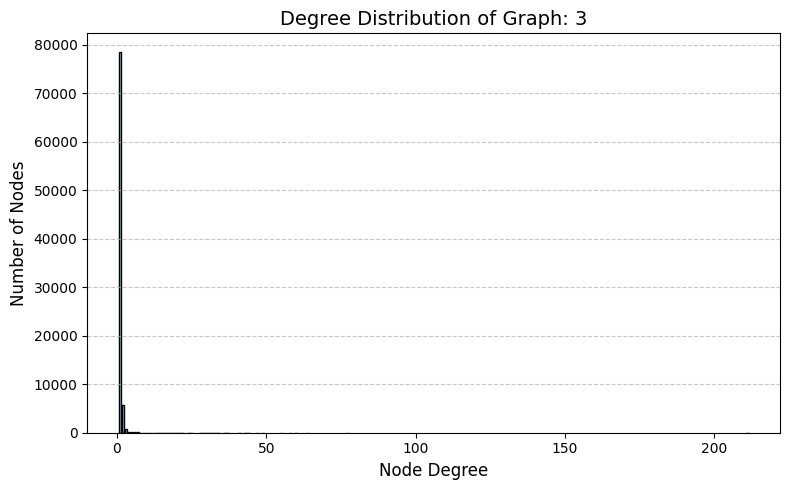

In [14]:
plot_deg_dist(g3, gid=3)